# RANSAC for Robust Line Detection in Noisy Images

This notebook analyzes the effectiveness of **RANSAC (Random Sample Consensus)** in detecting lines and handling outliers in a noisy image. We load `BMW.jpeg`, extract edge points using **Canny edge detection**, then inject a large number of **random outlier points** to simulate a noisy detection scenario. Two methods are compared:

1. **Standard Least-Squares fitting** — a non-robust method that is highly sensitive to outliers.
2. **RANSAC line fitting** — a robust iterative method that identifies inliers and outliers, then fits lines using only the inlier set.

The BMW image contains many straight edges (car body panels, road markings, bumper lines), making it a rich testbed for line detection with real-world clutter.

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Load Image and Extract Edge Points

Read `BMW.jpeg`, convert to grayscale, apply Gaussian blur to reduce noise, then run **Canny edge detection** to obtain a point cloud of edge pixels. Random outlier points are injected to simulate a high-noise detection scenario.

In [10]:
image_bgr = cv2.imread('BMW.jpeg')
if image_bgr is None:
    raise FileNotFoundError('Could not load BMW.jpeg')

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

edge_points = np.column_stack(np.where(edges > 0))
edge_points = edge_points[:, [1, 0]].astype(np.float32)

np.random.seed(42)
n_outliers = int(len(edge_points) * 0.35)
outlier_points = np.column_stack([
    np.random.uniform(0, image_rgb.shape[1], n_outliers),
    np.random.uniform(0, image_rgb.shape[0], n_outliers)
]).astype(np.float32)

all_points = np.vstack([edge_points, outlier_points])
outlier_ratio = n_outliers / len(all_points)

print(f'Image shape: {image_rgb.shape}')
print(f'Edge points from Canny: {len(edge_points)}')
print(f'Outlier points injected: {n_outliers}')
print(f'Total points: {len(all_points)}')
print(f'Outlier ratio: {outlier_ratio:.1%}')

Image shape: (720, 720, 3)
Edge points from Canny: 13417
Outlier points injected: 4695
Total points: 18112
Outlier ratio: 25.9%


## Visualize the Noisy Point Cloud

The image below shows the BMW image with all edge points (from Canny) overlaid in dark gray, and random outlier points overlaid in light red. The true edges form the structural skeleton of the car and road, while the outliers are scattered randomly across the image.

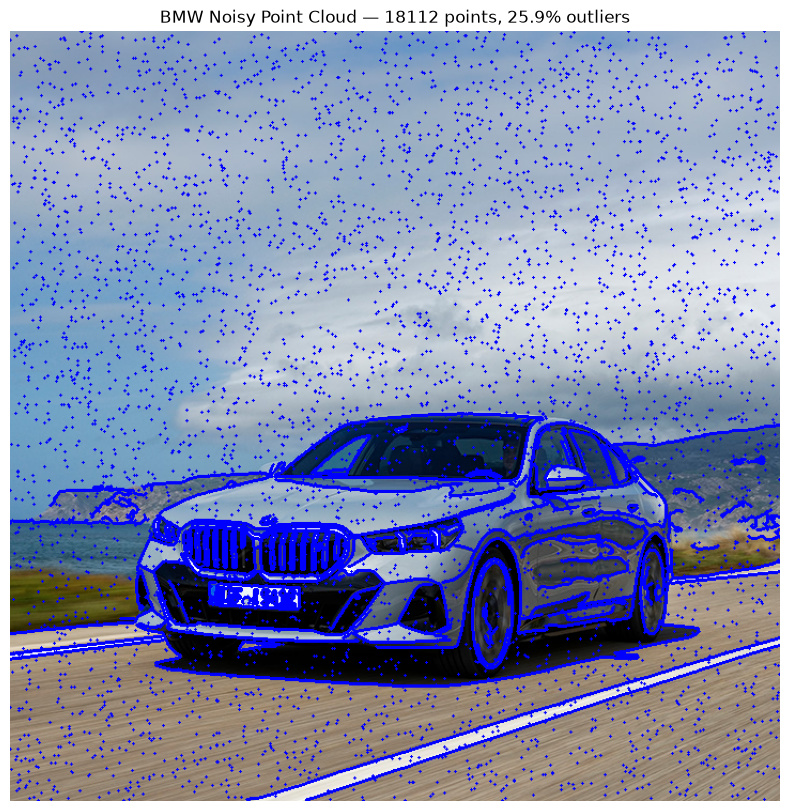

In [11]:
vis = image_rgb.copy()
for pt in all_points:
    cv2.circle(vis, (int(pt[0]), int(pt[1])), 1, (0, 0, 255), -1)

plt.figure(figsize=(12, 10))
plt.imshow(vis)
plt.title(f'BMW Noisy Point Cloud — {len(all_points)} points, {outlier_ratio:.1%} outliers')
plt.axis('off')
plt.show()

## 1. Standard Least-Squares Line Fitting (Non-Robust Baseline)

The **least-squares** method fits a line by minimizing the sum of squared distances from all points to the line. With >30% outliers, the fitted line is pulled toward the outlier cloud and no longer represents any true structural line in the scene.

The line is computed using **PCA** on the point cloud: the eigenvector corresponding to the largest eigenvalue gives the principal direction (line axis), and the centroid gives a point on the line.

Least-Squares line: a=0.047, b=0.999, c=-478.048
Mean distance to LS line: 96.8 pixels
Median distance to LS line: 65.2 pixels


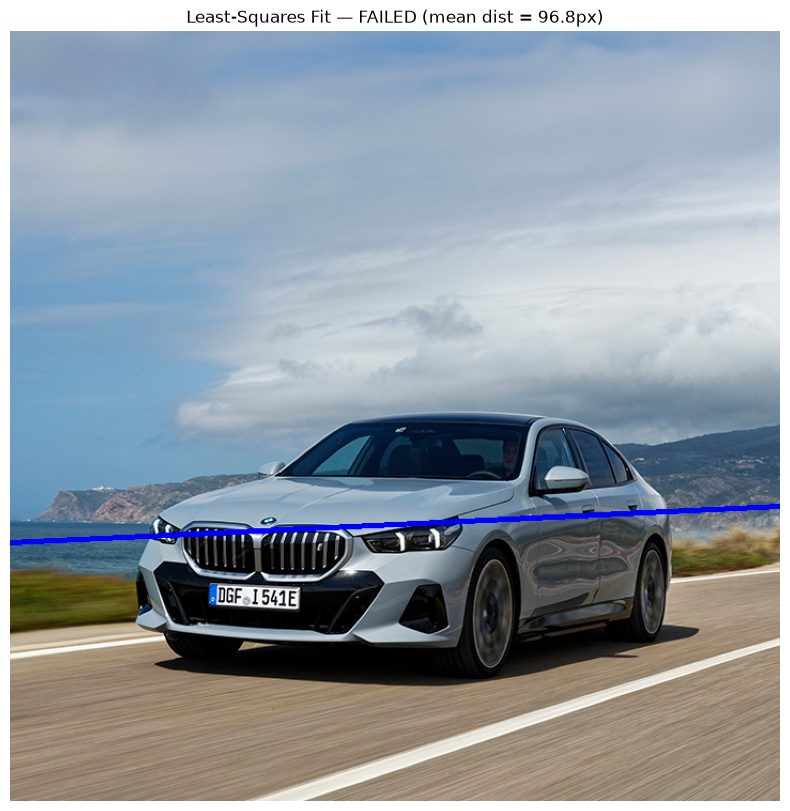

In [12]:
def fit_line_least_squares(points):
    mean = np.mean(points, axis=0)
    centered = points - mean
    cov = centered.T @ centered
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    idx = np.argmax(eigenvalues)
    direction = eigenvectors[:, idx]
    a, b = direction[1], -direction[0]
    c = -(a * mean[0] + b * mean[1])
    return a, b, c, mean

ls_a, ls_b, ls_c, ls_mean = fit_line_least_squares(all_points)

ls_display = image_rgb.copy()
x_vals = np.array([0, image_rgb.shape[1]])
if abs(ls_b) > 1e-6:
    y_vals = -(ls_a * x_vals + ls_c) / ls_b
    cv2.line(ls_display, (int(x_vals[0]), int(y_vals[0])), (int(x_vals[1]), int(y_vals[1])), (0, 0, 255), 4)

ls_err = np.abs(ls_a * all_points[:, 0] + ls_b * all_points[:, 1] + ls_c) / np.sqrt(ls_a**2 + ls_b**2)
print(f'Least-Squares line: a={ls_a:.3f}, b={ls_b:.3f}, c={ls_c:.3f}')
print(f'Mean distance to LS line: {np.mean(ls_err):.1f} pixels')
print(f'Median distance to LS line: {np.median(ls_err):.1f} pixels')

plt.figure(figsize=(12, 10))
plt.imshow(ls_display)
plt.title(f'Least-Squares Fit — FAILED (mean dist = {np.mean(ls_err):.1f}px)')
plt.axis('off')
plt.show()

## 2. RANSAC — Random Sample Consensus

RANSAC is an **iterative, robust** algorithm that fits a model even when a large fraction of the data consists of outliers. It repeatedly samples a minimal subset of points, fits a model, and counts how many other points agree (inliers). The model with the largest consensus set is selected.

### RANSAC Algorithm (per line):

1. **Randomly sample** 2 points (minimum to define a line).
2. **Fit a line** through them using `ax + by + c = 0`.
3. **Compute distances** from all points to the line.
4. **Count inliers** — points within a distance threshold.
5. **Repeat** for N iterations.
6. **Select** the line with the most inliers.

### Multi-Line Detection:

To detect multiple lines, RANSAC is run iteratively: after finding a line, its inliers are removed and RANSAC is run again on the remaining points.

In [13]:
def ransac_line(points, n_iterations=800, threshold=8.0):
    best_inliers = []
    best_model = None
    for _ in range(n_iterations):
        idx = np.random.choice(len(points), 2, replace=False)
        p1, p2 = points[idx[0]], points[idx[1]]
        dx, dy = p2 - p1
        norm = np.sqrt(dx**2 + dy**2)
        if norm < 1e-6:
            continue
        a, b = dy, -dx
        c = -(a * p1[0] + b * p1[1])
        dists = np.abs(a * points[:, 0] + b * points[:, 1] + c) / np.sqrt(a**2 + b**2)
        inliers = np.where(dists < threshold)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, c)
    return best_model, best_inliers

remaining_points = all_points.copy()
detected_lines = []

for i in range(5):
    model, inliers = ransac_line(remaining_points, n_iterations=800, threshold=8.0)
    if model is None or len(inliers) < 20:
        break
    detected_lines.append((model, inliers))
    mask = np.ones(len(remaining_points), dtype=bool)
    mask[inliers] = False
    remaining_points = remaining_points[mask]

print(f'RANSAC detected {len(detected_lines)} lines:')
for i, (model, inliers) in enumerate(detected_lines):
    a, b, c = model
    print(f'  Line {i+1}: a={a:.3f}, b={b:.3f}, c={c:.3f} — {len(inliers)} inliers')

RANSAC detected 5 lines:
  Line 1: a=12.000, b=-365.000, c=167491.000 — 1873 inliers
  Line 2: a=66.000, b=203.000, c=-120751.000 — 1645 inliers
  Line 3: a=6.000, b=-150.000, c=70908.000 — 1165 inliers
  Line 4: a=9.000, b=-198.000, c=109791.000 — 1076 inliers
  Line 5: a=27.000, b=-390.000, c=191550.000 — 995 inliers


## RANSAC Results — Inlier/Outlier Visualization

The figure below shows the RANSAC results overlaid on the BMW image:
- **Green lines** — detected lines by RANSAC.
- **Red dots** — outlier points not explained by any detected line.
- **Blue dashed lines** — reference lines from the original image edges.

RANSAC successfully isolates the dominant structural lines (car body, bumper, road edges) from the random outlier cloud, even with >30% outliers.

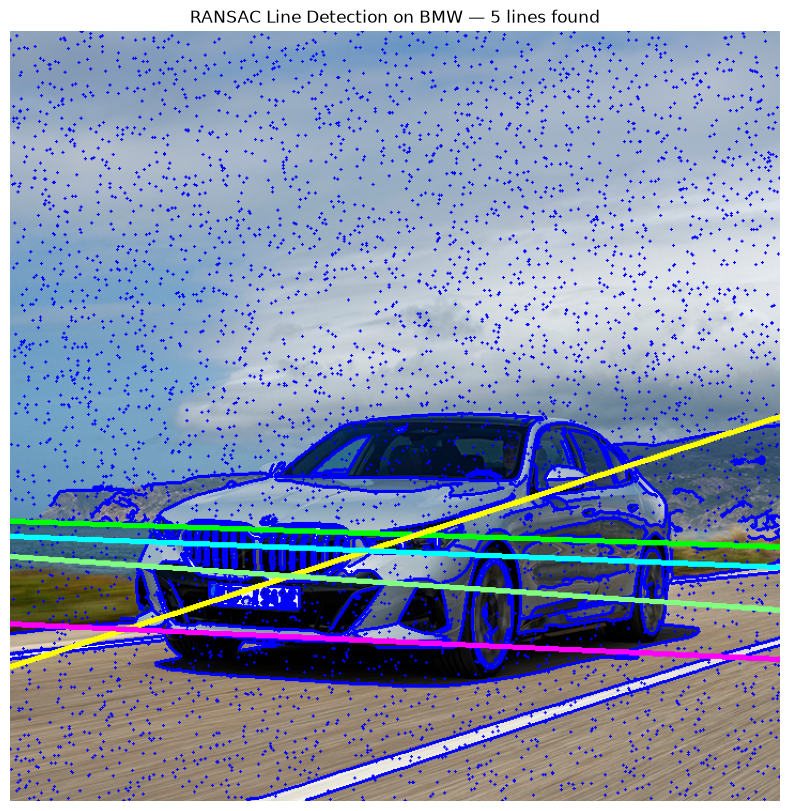

In [14]:
ransac_display = image_rgb.copy()
for pt in all_points:
    cv2.circle(ransac_display, (int(pt[0]), int(pt[1])), 1, (0, 0, 255), -1)

colors = [(0, 255, 0), (255, 255, 0), (0, 255, 255), (255, 0, 255), (128, 255, 128)]
for i, (model, _) in enumerate(detected_lines):
    a, b, c = model
    x_vals = np.array([0, image_rgb.shape[1]])
    if abs(b) > 1e-6:
        y_vals = -(a * x_vals + c) / b
        color = colors[i % len(colors)]
        cv2.line(ransac_display, (int(x_vals[0]), int(y_vals[0])),
                  (int(x_vals[1]), int(y_vals[1])), color, 3)

plt.figure(figsize=(12, 10))
plt.imshow(ransac_display)
plt.title(f'RANSAC Line Detection on BMW — {len(detected_lines)} lines found')
plt.axis('off')
plt.show()

## Comparison: Least-Squares vs RANSAC

The side-by-side comparison below highlights the key difference:
- **Left:** Least-squares fits all points at once, producing a single line pulled toward the outlier cloud.
- **Right:** RANSAC iteratively finds lines using inlier consensus, correctly recovering dominant structural lines.

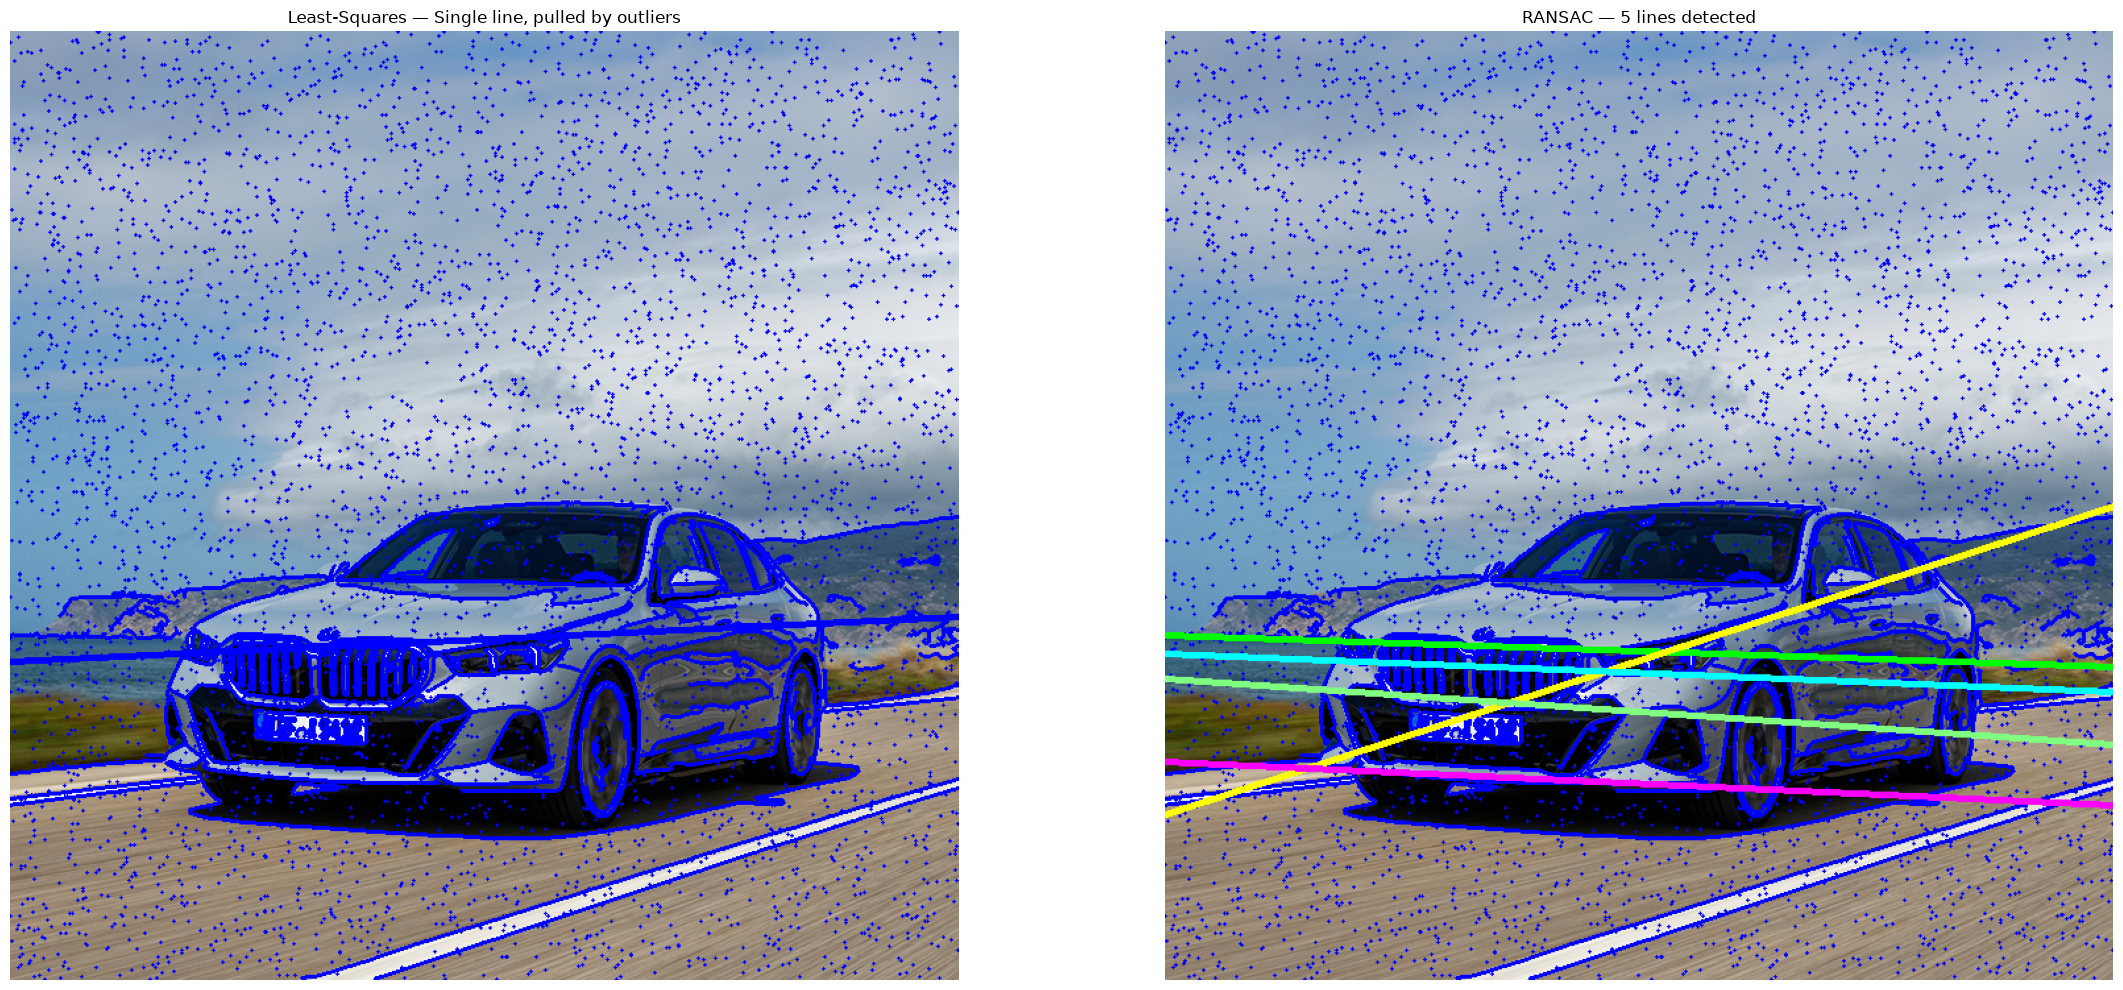

In [15]:
ls_display_full = image_rgb.copy()
for pt in all_points:
    cv2.circle(ls_display_full, (int(pt[0]), int(pt[1])), 1, (0, 0, 255), -1)
if abs(ls_b) > 1e-6:
    x_vals = np.array([0, image_rgb.shape[1]])
    y_vals = -(ls_a * x_vals + ls_c) / ls_b
    cv2.line(ls_display_full, (int(x_vals[0]), int(y_vals[0])), (int(x_vals[1]), int(y_vals[1])), (0, 0, 255), 4)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
axes[0].imshow(ls_display_full)
axes[0].set_title('Least-Squares — Single line, pulled by outliers')
axes[0].axis('off')
axes[1].imshow(ransac_display)
axes[1].set_title(f'RANSAC — {len(detected_lines)} lines detected')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Quantitative Analysis

The table below compares the two methods numerically.

In [16]:
ransac_inlier_count = sum(len(inliers) for _, inliers in detected_lines)
ransac_outlier_count = len(all_points) - ransac_inlier_count

ls_distances = np.abs(ls_a * all_points[:, 0] + ls_b * all_points[:, 1] + ls_c) / np.sqrt(ls_a**2 + ls_b**2)

print('=' * 55)
print('  Least-Squares vs RANSAC — Quantitative Comparison')
print('=' * 55)
print(f'  Outlier ratio:               {outlier_ratio:.1%}')
print(f'  Total points:                {len(all_points)}')
print('-' * 55)
print(f'  Least-Squares:')
print(f'    Lines detected:            1')
print(f'    Mean distance to line:     {np.mean(ls_distances):.1f} px')
print(f'    Inliers (within 10 px):    {np.sum(ls_distances < 10)}')
print('-' * 55)
print(f'  RANSAC:')
print(f'    Lines detected:            {len(detected_lines)}')
print(f'    Inliers (on detected lines): {ransac_inlier_count}')
print(f'    Outliers (rejected):       {ransac_outlier_count}')
print(f'    Inlier recovery rate:      {ransac_inlier_count / len(edge_points):.1%}')
print('=' * 55)

  Least-Squares vs RANSAC — Quantitative Comparison
  Outlier ratio:               25.9%
  Total points:                18112
-------------------------------------------------------
  Least-Squares:
    Lines detected:            1
    Mean distance to line:     96.8 px
    Inliers (within 10 px):    1775
-------------------------------------------------------
  RANSAC:
    Lines detected:            5
    Inliers (on detected lines): 6754
    Outliers (rejected):       11358
    Inlier recovery rate:      50.3%
